In [73]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

# Estilo general de visualizacion
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)

# Carga de datos
df = pd.read_csv('i40.csv')

print('Dimensiones del dataset:', df.shape)
print('\nTipos de datos:')
print(df.dtypes)
print('\nValores nulos por columna:')
print(df.isnull().sum())

display(df.head())

Dimensiones del dataset: (14521, 9)

Tipos de datos:
idx                   int64
parent_device_id      int64
product_type            str
air_temp [K]        float64
process_temp [K]    float64
speed [RPM]           int64
torque [Nm]         float64
tool_wear [min]       int64
target                  str
dtype: object

Valores nulos por columna:
idx                  0
parent_device_id     0
product_type         0
air_temp [K]        40
process_temp [K]     0
speed [RPM]          0
torque [Nm]          0
tool_wear [min]      0
target               0
dtype: int64


,idx,parent_device_id,product_type,air_temp [K],process_temp [K],speed [RPM],torque [Nm],tool_wear [min],target
0,0,5291,L,303.80,313.30,1406,52.10,166,normal
1,1,3908,L,302.30,311.20,1633,36.40,114,normal
2,2,10767,M,302.27,311.47,1228,68.75,187,failure
3,3,15484,L,302.35,311.93,1522,36.99,214,failure
4,4,784,L,296.70,307.90,1743,27.90,55,normal


## Parte 1 - Analisis exploratorio de datos (EDA)

En esta seccion se analizan:
- Medidas de tendencia central.
- Medidas de dispersion.
- Distribuciones.
- Proporciones.
- Relaciones entre variables.

In [74]:
# Variables numericas y categoricas
exclude_num_cols = {'idx', 'parent_device_id', 'parent_id'}
num_cols = [c for c in df.select_dtypes(include=np.number).columns if c not in exclude_num_cols]
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

print('Columnas numericas (sin idx y parent_id):', num_cols)
print('Columnas categoricas:', cat_cols)

# Medidas de tendencia central
central = pd.DataFrame({
    'media': df[num_cols].mean(numeric_only=True),
    'mediana': df[num_cols].median(numeric_only=True)
})

# Moda (puede haber mas de una, se toma la primera)
central['moda'] = [df[c].mode(dropna=True).iloc[0] if not df[c].mode(dropna=True).empty else np.nan for c in num_cols]

# Medidas de dispersion
dispersion = pd.DataFrame({
    'min': df[num_cols].min(numeric_only=True),
    'max': df[num_cols].max(numeric_only=True),
    'rango': df[num_cols].max(numeric_only=True) - df[num_cols].min(numeric_only=True),
    'varianza': df[num_cols].var(numeric_only=True),
    'desvio_std': df[num_cols].std(numeric_only=True),
    'coef_variacion': df[num_cols].std(numeric_only=True) / df[num_cols].mean(numeric_only=True)
})

print('--- Medidas de tendencia central ---')
display(central.round(3))
print('--- Medidas de dispersion ---')
display(dispersion.round(3))

Columnas numericas (sin idx y parent_id): ['air_temp [K]', 'process_temp [K]', 'speed [RPM]', 'torque [Nm]', 'tool_wear [min]']
Columnas categoricas: ['product_type', 'target']
--- Medidas de tendencia central ---


,media,mediana,moda
air_temp [K],300.479,300.60,300.7
process_temp [K],310.165,310.32,310.6
speed [RPM],1513.389,1423.00,1377.0
torque [Nm],44.956,46.70,35.8
tool_wear [min],124.922,127.00,208.0


--- Medidas de dispersion ---


,min,max,rango,varianza,desvio_std,coef_variacion
air_temp [K],295.3,304.5,9.2,3.813,1.953,0.006
process_temp [K],305.7,313.8,8.1,1.768,1.330,0.004
speed [RPM],-1.0,2886.0,2887.0,98347.575,313.604,0.207
torque [Nm],3.8,76.6,72.8,202.397,14.227,0.316
tool_wear [min],0.0,253.0,253.0,4914.850,70.106,0.561


In [75]:
# Resumen estadistico ampliado
summary = df[num_cols].describe(percentiles=[0.25, 0.5, 0.75]).T
summary['IQR'] = summary['75%'] - summary['25%']
summary['asimetria'] = df[num_cols].skew(numeric_only=True)
summary['curtosis'] = df[num_cols].kurt(numeric_only=True)

print('--- Resumen estadistico por variable numerica ---')
display(summary.round(3))

--- Resumen estadistico por variable numerica ---


,count,mean,std,min,25%,50%,75%,max,IQR,asimetria,curtosis
air_temp [K],14481.0,300.479,1.953,295.3,298.90,300.60,302.20,304.5,3.30,-0.220,-0.941
process_temp [K],14521.0,310.165,1.330,305.7,309.20,310.32,311.09,313.8,1.89,-0.220,-0.236
speed [RPM],14521.0,1513.389,313.604,-1.0,1354.00,1423.00,1561.00,2886.0,207.00,2.080,7.991
torque [Nm],14521.0,44.956,14.227,3.8,35.99,46.70,55.00,76.6,19.01,-0.522,-0.024
tool_wear [min],14521.0,124.922,70.106,0.0,64.00,127.00,193.00,253.0,129.00,-0.165,-1.295


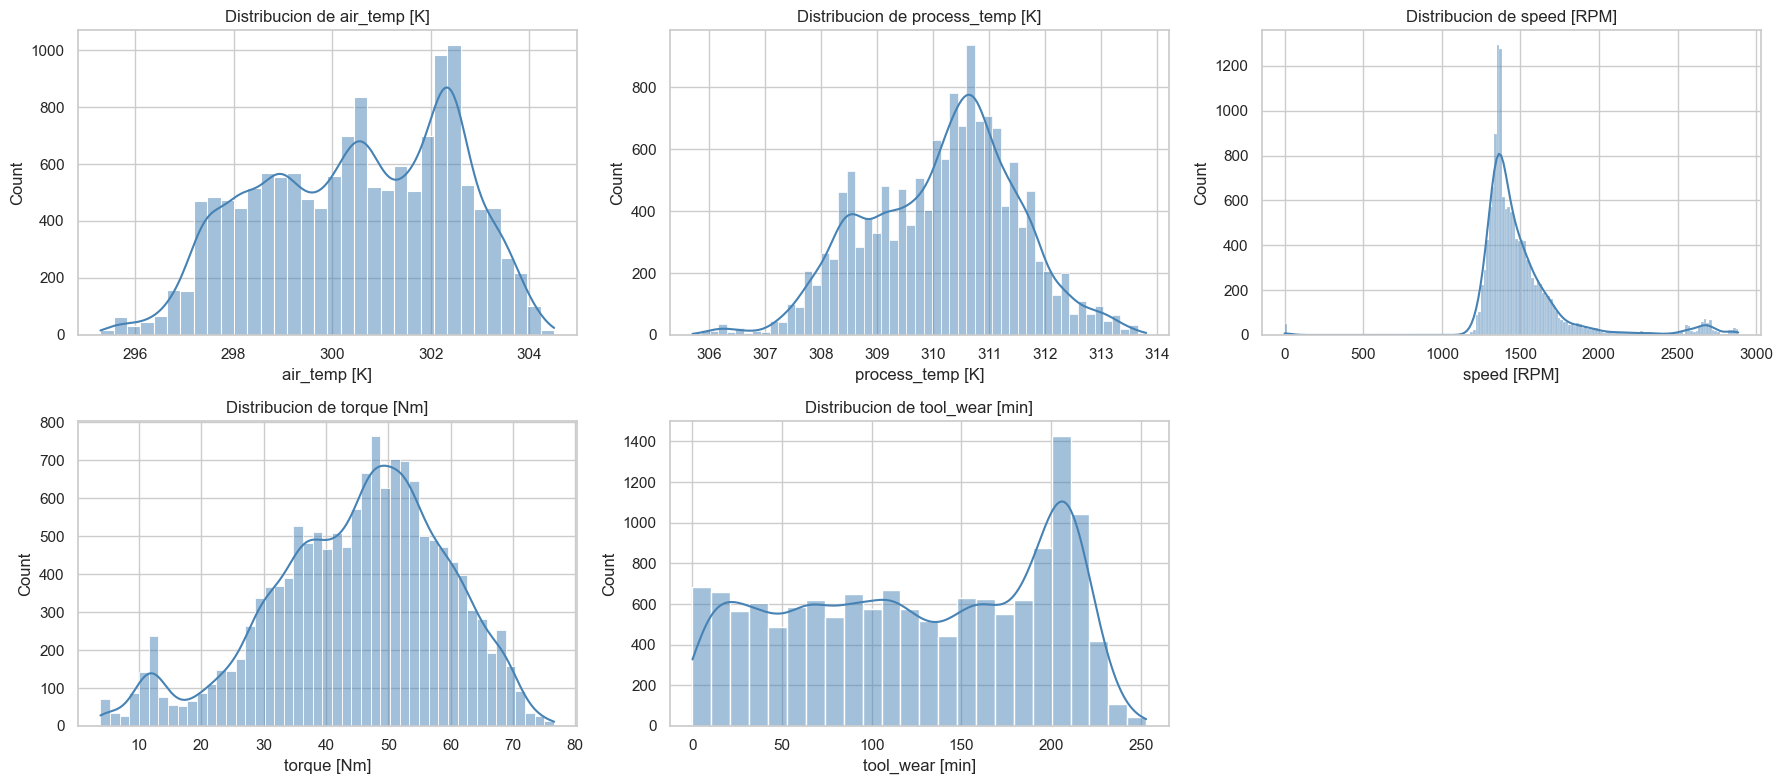

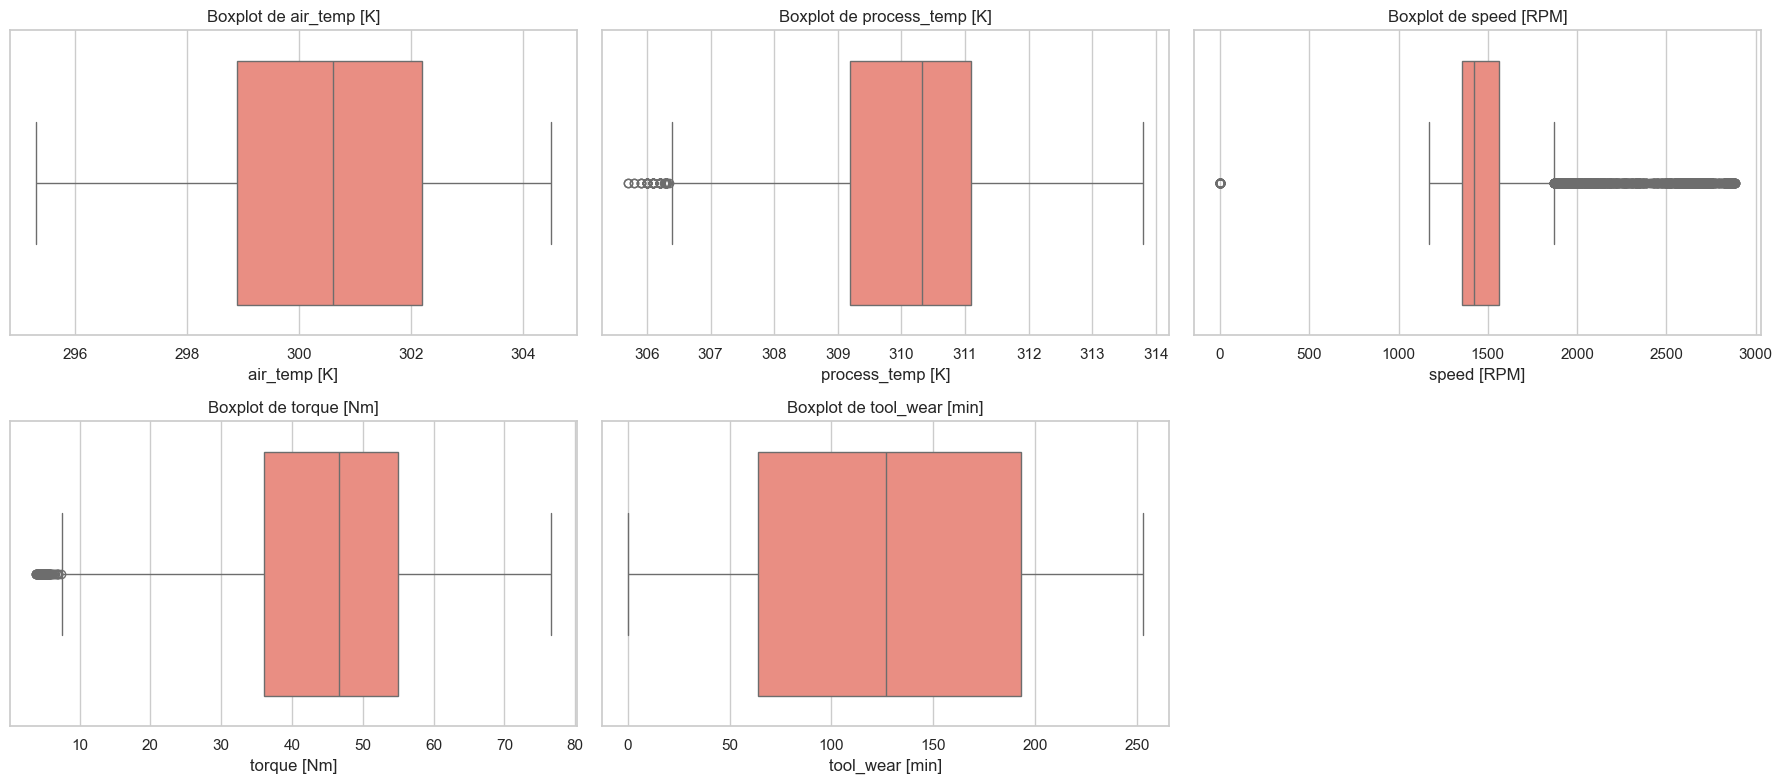

In [76]:
# Distribuciones: histogramas con KDE
n = len(num_cols)
rows = int(np.ceil(n / 3))
fig, axes = plt.subplots(rows, 3, figsize=(18, 4 * rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribucion de {col}')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

# Boxplots para detectar dispersion y posibles outliers
fig, axes = plt.subplots(rows, 3, figsize=(18, 4 * rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='salmon')
    axes[i].set_title(f'Boxplot de {col}')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


--- Proporciones de product_type (%) ---


,porcentaje
product_type,
L,71.36
M,18.53
H,10.11


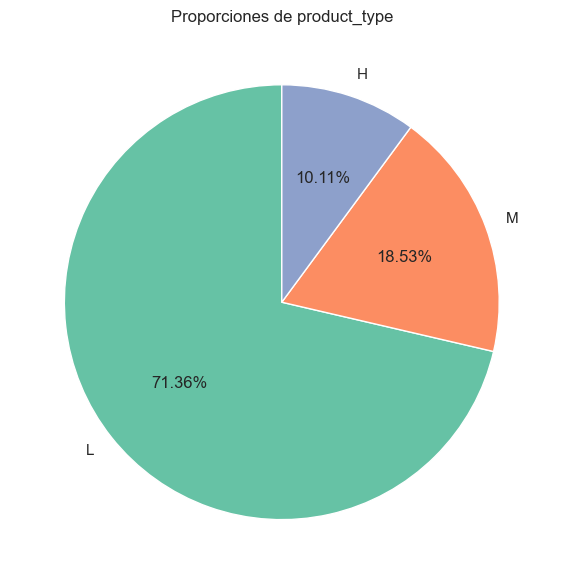


--- Proporciones de target (%) ---


,porcentaje
target,
failure,51.53
normal,48.47


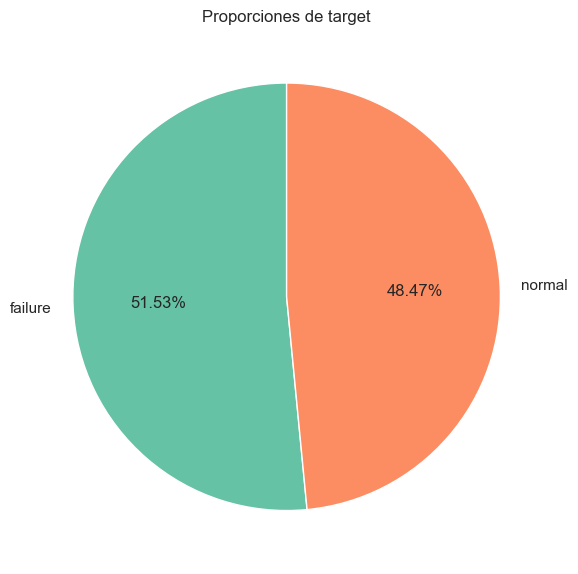

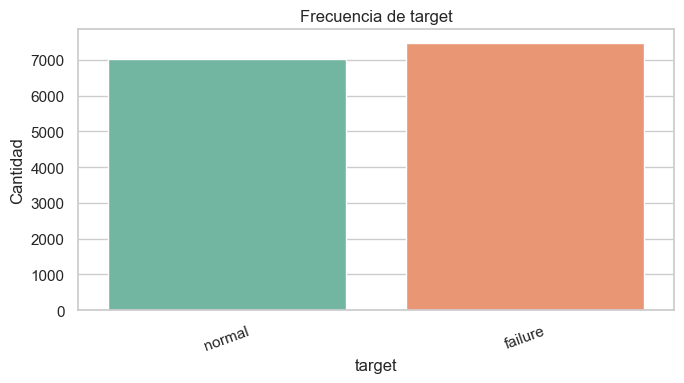

In [42]:
# Proporciones de variables categoricas
for col in cat_cols:
    prop = df[col].value_counts(normalize=True).mul(100).round(2)
    print(f'\n--- Proporciones de {col} (%) ---')
    display(prop.to_frame(name='porcentaje'))

    counts = df[col].value_counts()
    plt.figure(figsize=(6, 6))
    plt.pie(counts, labels=counts.index, autopct='%1.2f%%', colors=sns.color_palette('Set2'), startangle=90)
    plt.title(f'Proporciones de {col}')
    plt.tight_layout()
    plt.show()

 # Grafico de barras de target
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='target', hue='target', palette='Set2', legend=False)
plt.title(f'Frecuencia de target')
plt.xlabel(col)
plt.ylabel('Cantidad')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

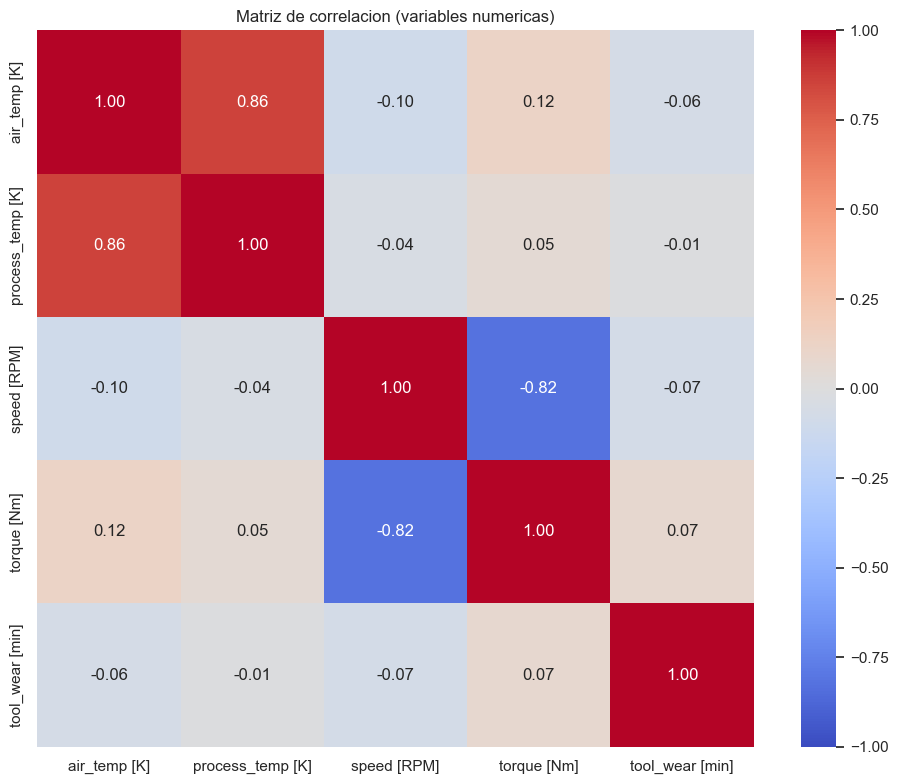

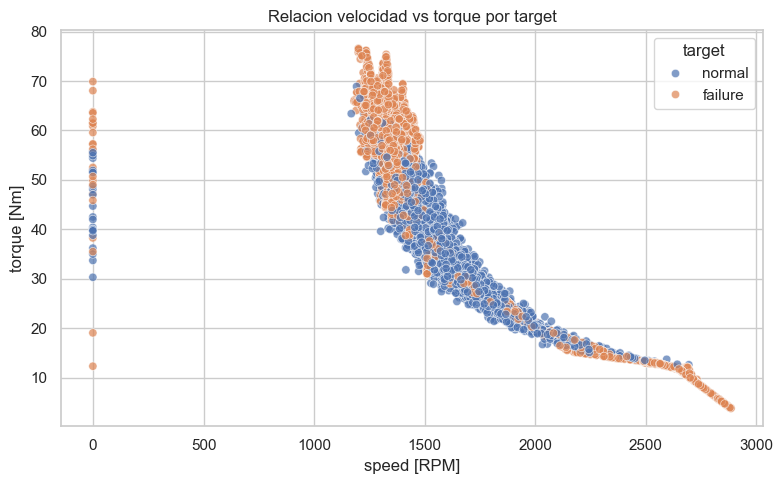

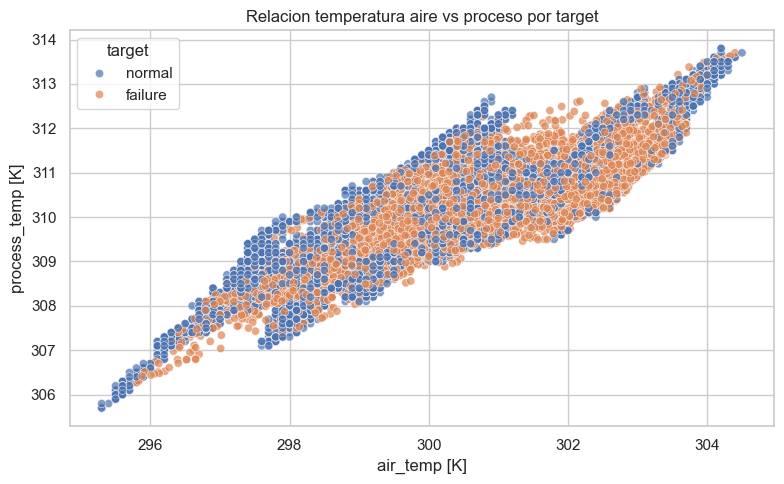

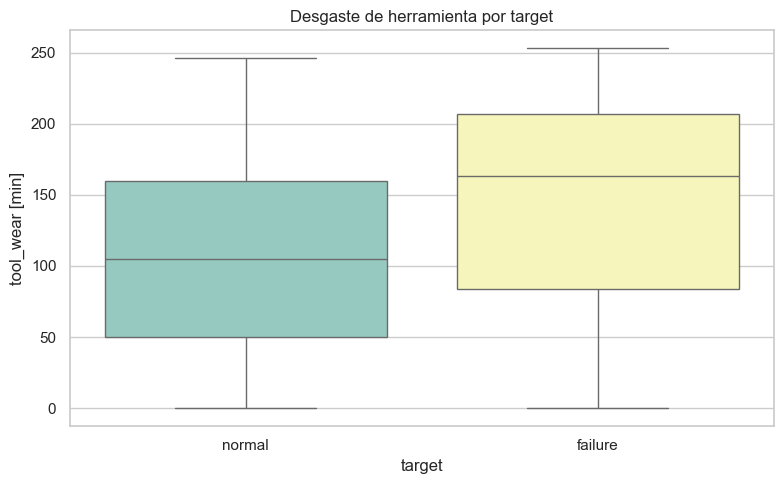

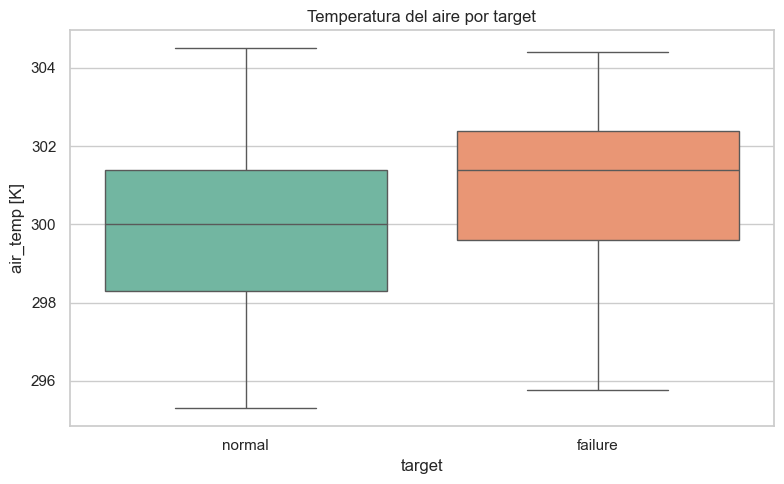

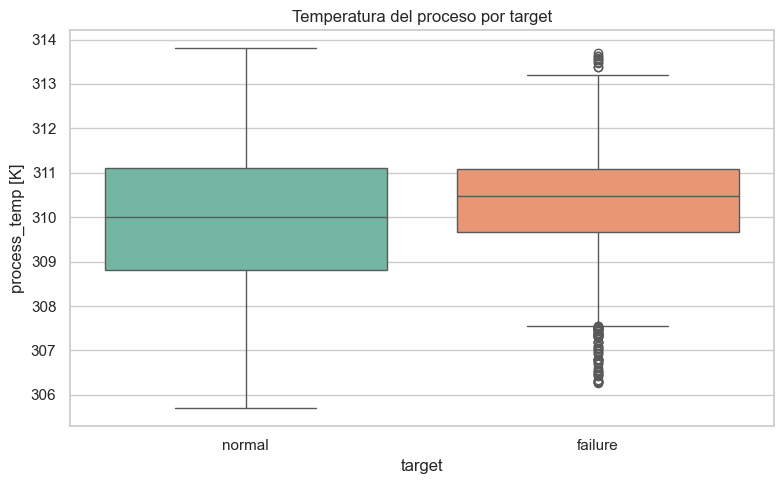

--- Proporcion de product_type por target ---


target,failure,normal
product_type,,
H,0.098,0.104
L,0.829,0.591
M,0.073,0.304


In [78]:
# Relaciones entre variables numericas: correlacion
corr = df[num_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, vmin=-1, vmax=1)
plt.title('Matriz de correlacion (variables numericas)')
plt.tight_layout()
plt.show()

# Relacion entre variables y clase objetivo (si existe)
if 'target' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x='speed [RPM]', y='torque [Nm]', hue='target', alpha=0.7)
    plt.title('Relacion velocidad vs torque por target')
    plt.tight_layout()
    plt.show()
    
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x='air_temp [K]', y='process_temp [K]', hue='target', alpha=0.7)
    plt.title('Relacion temperatura aire vs proceso por target')
    plt.tight_layout()
    plt.show()


    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x='target', y='tool_wear [min]', hue='target', palette='Set3', legend=False)
    plt.title('Desgaste de herramienta por target')
    plt.tight_layout()
    plt.show()

    # Relacion analoga: RPM (speed) vs target
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x='target', y='air_temp [K]', hue='target', palette='Set2', legend=False)
    plt.title('Temperatura del aire por target')
    plt.tight_layout()
    plt.show()
    
    # Relacion analoga: RPM (speed) vs target
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x='target', y='process_temp [K]', hue='target', palette='Set2', legend=False)
    plt.title('Temperatura del proceso por target')
    plt.tight_layout()
    plt.show()

    # Tabla cruzada de proporciones
    if 'product_type' in df.columns:
        cross = pd.crosstab(df['product_type'], df['target'], normalize='columns').round(3)
        print('--- Proporcion de product_type por target ---')
        display(cross)

## Conclusiones principales

- La variable `target` esta relativamente balanceada: ~51.53% `failure` y ~48.47% `normal`.
- `product_type` esta desbalanceada a favor de `L` (~71.36%), seguida de `M` y `H`.
- Hay una correlacion positiva alta entre `air_temp [K]` y `process_temp [K]` (~0.86).
- Hay una correlacion negativa fuerte entre `speed [RPM]` y `torque [Nm]` (~-0.82).
- El `tool_wear [min]` tiende a ser mayor en observaciones con `failure` que en `normal`.
- Se observan valores atipicos en `speed [RPM]` y en menor medida en otras variables, visibles en los boxplots.

## Parte 2 - Preprocesamiento para modelos de aprendizaje automatico

En esta seccion se realiza el preprocesamiento del dataset para dejarlo listo para modelado.

In [79]:
# 1) Analisis de variables y limpieza inicial

df_prep = df.copy()

# Definiciones de columnas
id_cols = [c for c in ['idx', 'parent_device_id', 'parent_id'] if c in df_prep.columns]
target_col = 'target'

if target_col not in df_prep.columns:
    raise ValueError('No se encontro la columna target en el dataset.')

# Eliminar identificadores para modelado
if id_cols:
    df_prep = df_prep.drop(columns=id_cols)

# Separar tipos de variables
num_cols_prep = [c for c in df_prep.select_dtypes(include=np.number).columns if c != target_col]
cat_cols_prep = [c for c in df_prep.select_dtypes(exclude=np.number).columns if c != target_col]

print('Columnas eliminadas (identificadores):', id_cols)
print('Variables numericas para modelado:', num_cols_prep)
print('Variables categoricas para modelado:', cat_cols_prep)
print('Variable objetivo:', target_col)

# Valores faltantes y duplicados
missing_before = df_prep.isnull().sum().sort_values(ascending=False)
print('\nValores faltantes antes de imputar:')
display(missing_before[missing_before > 0].to_frame('nulos'))

print('Filas duplicadas:', int(df_prep.duplicated().sum()))
df_prep = df_prep.drop_duplicates().reset_index(drop=True)

# Valores erroneos simples (RPM no puede ser <= 0)
if 'speed [RPM]' in df_prep.columns:
    wrong_rpm = (df_prep['speed [RPM]'] <= 0).sum()
    print('Registros con RPM <= 0:', int(wrong_rpm))
    df_prep.loc[df_prep['speed [RPM]'] <= 0, 'speed [RPM]'] = np.nan

# Imputacion con KMeans para pares de variables fuertemente correlacionadas
from sklearn.cluster import KMeans

def impute_with_kmeans(df, target_col, predictor_col, n_clusters=5):
    """
    Imputa los NaN de target_col usando KMeans entrenado sobre
    los registros validos de (predictor, target). Asigna el valor
    del centroide mas cercano en la dimension del predictor.
    """
    nan_mask = df[target_col].isna()
    if nan_mask.sum() == 0:
        return df

    # Si el predictor tambien es NaN en esos registros, no se puede imputar ahora
    usable_mask = nan_mask & df[predictor_col].notna()
    if usable_mask.sum() == 0:
        return df

    valid = df[target_col].notna()
    if valid.sum() < 2:
        return df

    n = min(n_clusters, int(valid.sum()))
    kmeans = KMeans(n_clusters=n, random_state=42, n_init=10)
    kmeans.fit(df.loc[valid, [predictor_col, target_col]])

    centroids = kmeans.cluster_centers_
    for idx in df[usable_mask].index:
        p_val = df.at[idx, predictor_col]
        nearest = np.argmin(np.abs(centroids[:, 0] - p_val))
        df.at[idx, target_col] = centroids[nearest, 1]

    return df

# Speed vs Torque (corr ~ -0.925)
if 'speed [RPM]' in df_prep.columns and 'torque [Nm]' in df_prep.columns:
    df_prep = impute_with_kmeans(df_prep, 'speed [RPM]', 'torque [Nm]')

# Air temp vs Process temp (corr ~ 0.858)
if 'air_temp [K]' in df_prep.columns and 'process_temp [K]' in df_prep.columns:
    df_prep = impute_with_kmeans(df_prep, 'air_temp [K]', 'process_temp [K]')

# Imputacion de faltantes para el resto (median/moda)
for c in num_cols_prep:
    df_prep[c] = df_prep[c].fillna(df_prep[c].median())
for c in cat_cols_prep:
    moda = df_prep[c].mode(dropna=True)
    if not moda.empty:
        df_prep[c] = df_prep[c].fillna(moda.iloc[0])

print('\nValores faltantes despues de imputar:')
display(df_prep.isnull().sum().to_frame('nulos'))

Columnas eliminadas (identificadores): ['idx', 'parent_device_id']
Variables numericas para modelado: ['air_temp [K]', 'process_temp [K]', 'speed [RPM]', 'torque [Nm]', 'tool_wear [min]']
Variables categoricas para modelado: ['product_type']
Variable objetivo: target

Valores faltantes antes de imputar:


,nulos
air_temp [K],40


Filas duplicadas: 72
Registros con RPM <= 0: 47

Valores faltantes despues de imputar:


,nulos
product_type,0
air_temp [K],0
process_temp [K],0
speed [RPM],0
torque [Nm],0
tool_wear [min],0
target,0


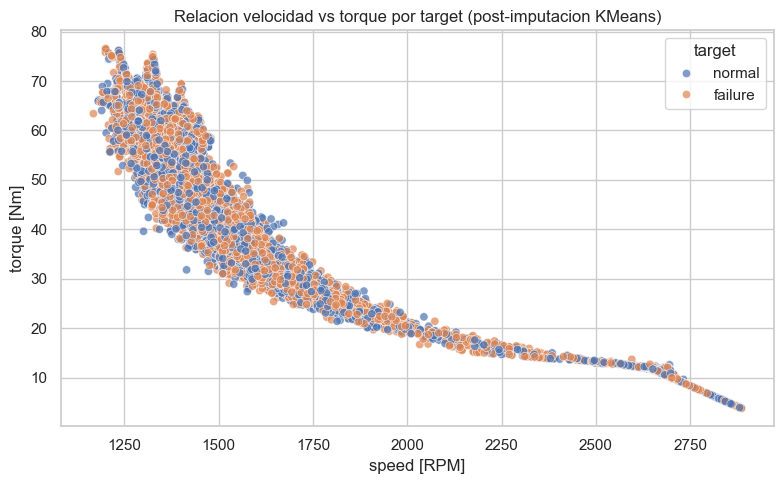

In [80]:
# Scatter post-imputacion KMeans: speed vs torque (con target original)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_prep, x='speed [RPM]', y='torque [Nm]', hue=df['target'], alpha=0.7)
plt.title('Relacion velocidad vs torque por target (post-imputacion KMeans)')
plt.tight_layout()
plt.show()


In [81]:
# Eliminacion de variables altamente correlacionadas (antes del clipping)
# Criterio: para pares con |correlacion| > 0.88, se elimina la variable
# que tenga mayor correlacion promedio con el resto de las features.

corr_matrix = df_prep[num_cols_prep].corr(numeric_only=True).abs()
display(corr_matrix.round(3))
# Media de correlacion absoluta de cada variable con las demas
mean_corr = corr_matrix.mean(axis=1)

umbral = 0.88
cols_to_drop = set()
cols = corr_matrix.columns.tolist()

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        if corr_matrix.iloc[i, j] > umbral:
            var_i = cols[i]
            var_j = cols[j]
            # Eliminar la que tenga mayor correlacion promedio con el resto
            if mean_corr[var_i] > mean_corr[var_j]:
                cols_to_drop.add(var_i)
            else:
                cols_to_drop.add(var_j)

if cols_to_drop:
    print('Variables eliminadas por alta correlacion:', sorted(cols_to_drop))
    df_prep = df_prep.drop(columns=list(cols_to_drop))
    num_cols_prep = [c for c in num_cols_prep if c not in cols_to_drop]
else:
    print(f'No se detectaron pares con correlacion > {umbral}')

print('Variables numericas restantes:', num_cols_prep)

,air_temp [K],process_temp [K],speed [RPM],torque [Nm],tool_wear [min]
air_temp [K],1.000,0.860,0.103,0.123,0.064
process_temp [K],0.860,1.000,0.042,0.052,0.014
speed [RPM],0.103,0.042,1.000,0.852,0.077
torque [Nm],0.123,0.052,0.852,1.000,0.072
tool_wear [min],0.064,0.014,0.077,0.072,1.000


No se detectaron pares con correlacion > 0.88
Variables numericas restantes: ['air_temp [K]', 'process_temp [K]', 'speed [RPM]', 'torque [Nm]', 'tool_wear [min]']


In [82]:
# 2) Valores atipicos (IQR) y tratamiento
outlier_summary = []

for c in num_cols_prep:
    q1 = df_prep[c].quantile(0.25)
    q3 = df_prep[c].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    out_count = ((df_prep[c] < lower) | (df_prep[c] > upper)).sum()
    outlier_summary.append({
        'variable': c,
        'outliers': int(out_count),
        'porcentaje_outliers': round(100 * out_count / len(df_prep), 2)
    })

    # Para speed [RPM] omitimos clipping (los valores altos son reales)
    if c != 'speed [RPM]':
        # Clipping para limitar el impacto de extremos sin eliminar filas
        df_prep[c] = df_prep[c].clip(lower=lower, upper=upper)

outlier_df = pd.DataFrame(outlier_summary).sort_values('porcentaje_outliers', ascending=False)
print('Resumen de outliers detectados (antes del tratamiento):')
display(outlier_df)

Resumen de outliers detectados (antes del tratamiento):


,variable,outliers,porcentaje_outliers
2,speed [RPM],1128,7.81
3,torque [Nm],106,0.73
1,process_temp [K],67,0.46
0,air_temp [K],0,0.00
4,tool_wear [min],0,0.00


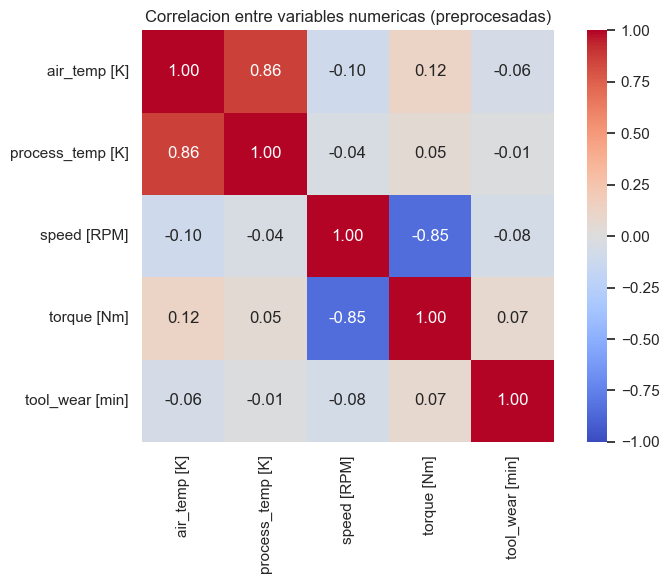

Pares con |correlacion| >= 0.8:


,var_1,var_2,corr
0,air_temp [K],process_temp [K],0.86
1,speed [RPM],torque [Nm],-0.85


In [83]:
# 3) Correlacion entre variables
corr_prep = df_prep[num_cols_prep].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_prep, annot=True, fmt='.2f', cmap='coolwarm', square=True, vmin=-1, vmax=1)
plt.title('Correlacion entre variables numericas (preprocesadas)')
plt.tight_layout()
plt.show()

# Pares con alta correlacion absoluta
threshold = 0.8
high_corr_pairs = []
cols = corr_prep.columns.tolist()
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        val = corr_prep.iloc[i, j]
        if abs(val) >= threshold:
            high_corr_pairs.append((cols[i], cols[j], round(float(val), 3)))

print(f'Pares con |correlacion| >= {threshold}:')
if high_corr_pairs:
    display(pd.DataFrame(high_corr_pairs, columns=['var_1', 'var_2', 'corr'], ))
else:
    print('No se detectaron pares por encima del umbral.')

In [84]:
from imblearn.under_sampling import RandomUnderSampler
# 4) Procesamiento de categoricas, balance y normalizacion

# Separacion X/y
y = df_prep[target_col].copy()
X = df_prep.drop(columns=[target_col]).copy()

# Codificacion de variables categoricas con one-hot encoding
X_encoded = pd.get_dummies(X, columns=cat_cols_prep, drop_first=True)

# Variable objetivo a binaria para modelos de clasificacion
# failure -> 1, normal -> 0
y_bin = y.map({'failure': 1, 'normal': 0})

print('Shape X original:', X.shape)
print('Shape X codificada:', X_encoded.shape)
print('Distribucion original de target:')
display((y.value_counts(normalize=True) * 100).round(2).to_frame('porcentaje'))

# Balance del conjunto de datos (undersampling de la clase mayoritaria)
# Reducir la mayoritaria en proporcion segun la variable minoritaria.
undersampler = RandomUnderSampler()
X_bal, y_bal = undersampler.fit_resample(X_encoded, y_bin)

print('Distribucion balanceada de target_bin:')
display((y_bal.value_counts(normalize=True) * 100).round(2).to_frame('porcentaje'))

# Normalizacion estandar (z-score) en columnas numericas
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
num_cols_encoded = [c for c in num_cols_prep if c in X_bal.columns
]
X_scaled = X_bal.copy()
X_scaled[num_cols_encoded] = scaler.fit_transform(X_scaled[num_cols_encoded])   


print('Columnas normalizadas (z-score):', num_cols_encoded)
print('Shape final X_scaled:', X_scaled.shape)
print('Shape final y_bal:', y_bal.shape)

display(X_scaled.head())

Shape X original: (14449, 6)
Shape X codificada: (14449, 7)
Distribucion original de target:


,porcentaje
target,
failure,51.28
normal,48.72


Distribucion balanceada de target_bin:


,porcentaje
target,
0,50.0
1,50.0


Columnas normalizadas (z-score): ['air_temp [K]', 'process_temp [K]', 'speed [RPM]', 'torque [Nm]', 'tool_wear [min]']
Shape final X_scaled: (14078, 7)
Shape final y_bal: (14078,)


,air_temp [K],process_temp [K],speed [RPM],torque [Nm],tool_wear [min],product_type_L,product_type_M
0,1.703987,2.353778,-0.377076,0.516469,0.591362,True,False
1,0.937469,0.777799,0.384787,-0.598661,-0.150975,True,False
4,-1.924198,-1.698741,0.753972,-1.202394,-0.993242,True,False
5,-1.106579,-0.723134,-0.108578,-0.172497,-1.549995,False,False
9,0.784166,0.252472,1.082882,-1.507812,-0.079596,False,False


## Parte 2 - Modelos de Clasificacion

Se entrenan y evaluan los modelos vistos en el curso:
- Division del conjunto de datos para entrenamiento y prueba.
- Busqueda de hiperparametros para mejorar el rendimiento.
- Evaluacion con metricas convenientes (accuracy, precision, recall, F1, matriz de confusion, ROC AUC).

In [85]:
# Imports de modelos y herramientas de evaluacion
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import time
import pickle
import psutil

train_times = {}
model_memory = {}

### Division del conjunto de datos

Se separa el conjunto preprocesado (`X_scaled`, `y_bal`) en entrenamiento (70 %) y prueba (30 %), conservando la estratificacion de clases.

In [86]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_bal, test_size=0.30, random_state=42, stratify=y_bal
)

print('Train shape:', X_train.shape, y_train.shape)
print('Test shape:', X_test.shape, y_test.shape)
print('Distribucion en train:')
print(y_train.value_counts(normalize=True).round(3))
print('Distribucion en test:')
print(y_test.value_counts(normalize=True).round(3))

Train shape: (9854, 7) (9854,)
Test shape: (4224, 7) (4224,)
Distribucion en train:
target
1    0.5
0    0.5
Name: proportion, dtype: float64
Distribucion en test:
target
0    0.5
1    0.5
Name: proportion, dtype: float64


In [87]:
# Mostrar proporción de registros L, M, H en el conjunto de test en base a las columnas product_typeL y product_typeM (es H si ambas son False)

prop_L = X_test['product_type_L'].mean()
prop_M = X_test['product_type_M'].mean()
prop_H = (~X_test['product_type_L'] & ~X_test['product_type_M']).mean()

print(f'Proporcion de product_type L (product_type_L=True): {prop_L:.4f} ({prop_L*100:.1f}%)')
print(f'Proporcion de product_type M (product_type_M=True): {prop_M:.4f} ({prop_M*100:.1f}%)')
print(f'Proporcion de product_type H (ambas False):       {prop_H:.4f} ({prop_H*100:.1f}%)')
print(f'Total:                                                {prop_L + prop_M + prop_H:.4f}')


Proporcion de product_type L (product_type_L=True): 0.6963 (69.6%)
Proporcion de product_type M (product_type_M=True): 0.1970 (19.7%)
Proporcion de product_type H (ambas False):       0.1068 (10.7%)
Total:                                                1.0000


In [88]:
# Output de train y test dataset
train_data = X_train.copy()
train_data[target_col] = y_train

test_data = X_test.copy()
test_data[target_col] = y_test


train_data.to_csv('train_data.csv', index=False)
test_data.to_csv('test_data.csv', index=False)

### Estrategia de validacion cruzada

Se utiliza `StratifiedKFold` con 5 folds para todas las busquedas de hiperparametros.

In [89]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### Modelo 1 - Regresion Logistica

In [90]:
lr = LogisticRegression(max_iter=1000, random_state=42)
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear']
}
grid_lr = GridSearchCV(estimator=lr, param_grid=param_grid_lr, scoring='f1', cv=cv, n_jobs=-1, verbose=1)
start_lr = time.perf_counter()
grid_lr.fit(X_train, y_train)
train_times['Regresion Logistica'] = time.perf_counter() - start_lr
print('Mejores hiperparametros (LR):', grid_lr.best_params_)
print('Mejor F1 en CV (LR):', round(grid_lr.best_score_, 4))
model_memory['Regresion Logistica'] = len(pickle.dumps(grid_lr.best_estimator_)) / 1024

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Mejores hiperparametros (LR): {'C': 0.1, 'solver': 'lbfgs'}
Mejor F1 en CV (LR): 0.845


In [91]:
y_pred_lr = grid_lr.predict(X_test)
y_proba_lr = grid_lr.predict_proba(X_test)[:, 1]
acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)
print('=== Regresion Logistica - Test ===')
print(f'Accuracy : {acc_lr:.4f}')
print(f'Precision: {prec_lr:.4f}')
print(f'Recall   : {rec_lr:.4f}')
print(f'F1-Score : {f1_lr:.4f}')
print(f'ROC AUC  : {auc_lr:.4f}')
print(classification_report(y_test, y_pred_lr, target_names=['normal', 'failure']))

=== Regresion Logistica - Test ===
Accuracy : 0.8355
Precision: 0.8303
Recall   : 0.8433
F1-Score : 0.8367
ROC AUC  : 0.9192
              precision    recall  f1-score   support

      normal       0.84      0.83      0.83      2112
     failure       0.83      0.84      0.84      2112

    accuracy                           0.84      4224
   macro avg       0.84      0.84      0.84      4224
weighted avg       0.84      0.84      0.84      4224



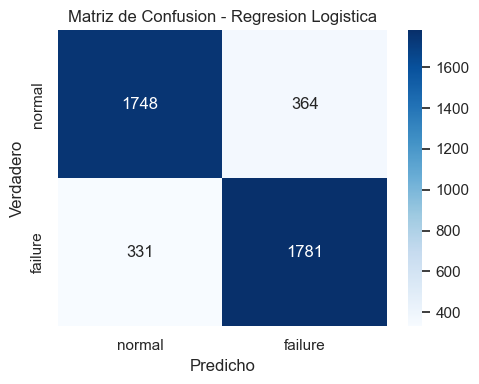

In [92]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=['normal','failure'], yticklabels=['normal','failure'])
plt.title('Matriz de Confusion - Regresion Logistica')
plt.ylabel('Verdadero'); plt.xlabel('Predicho')
plt.tight_layout(); plt.show()

### Modelo 2 - Naive Bayes (GaussianNB)

In [93]:
nb_model = GaussianNB()
# GaussianNB tiene pocos hiperparametros; se varia var_smoothing en escala logaritmica
param_grid_nb = {
    'var_smoothing': np.logspace(-12, -6, num=7)
}
grid_nb = GridSearchCV(estimator=nb_model, param_grid=param_grid_nb, scoring='f1', cv=cv, n_jobs=-1, verbose=1)
start_nb = time.perf_counter()
grid_nb.fit(X_train, y_train)
train_times['Naive Bayes'] = time.perf_counter() - start_nb
print('Mejores hiperparametros (NB):', grid_nb.best_params_)
print('Mejor F1 en CV (NB):', round(grid_nb.best_score_, 4))
model_memory['Naive Bayes'] = len(pickle.dumps(grid_nb.best_estimator_)) / 1024

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Mejores hiperparametros (NB): {'var_smoothing': np.float64(1e-12)}
Mejor F1 en CV (NB): 0.8108


In [94]:
y_pred_nb = grid_nb.predict(X_test)
y_proba_nb = grid_nb.predict_proba(X_test)[:, 1]
acc_nb = accuracy_score(y_test, y_pred_nb)
prec_nb = precision_score(y_test, y_pred_nb)
rec_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)
auc_nb = roc_auc_score(y_test, y_proba_nb)
print('=== Naive Bayes - Test ===')
print(f'Accuracy : {acc_nb:.4f}')
print(f'Precision: {prec_nb:.4f}')
print(f'Recall   : {rec_nb:.4f}')
print(f'F1-Score : {f1_nb:.4f}')
print(f'ROC AUC  : {auc_nb:.4f}')
print(classification_report(y_test, y_pred_nb, target_names=['normal', 'failure']))

=== Naive Bayes - Test ===
Accuracy : 0.8037
Precision: 0.7592
Recall   : 0.8897
F1-Score : 0.8193
ROC AUC  : 0.8884
              precision    recall  f1-score   support

      normal       0.87      0.72      0.79      2112
     failure       0.76      0.89      0.82      2112

    accuracy                           0.80      4224
   macro avg       0.81      0.80      0.80      4224
weighted avg       0.81      0.80      0.80      4224


Accuracy : 0.8037
Precision: 0.7592
Recall   : 0.8897
F1-Score : 0.8193
ROC AUC  : 0.8884
              precision    recall  f1-score   support

      normal       0.87      0.72      0.79      2112
     failure       0.76      0.89      0.82      2112

    accuracy                           0.80      4224
   macro avg       0.81      0.80      0.80      4224
weighted avg       0.81      0.80      0.80      4224



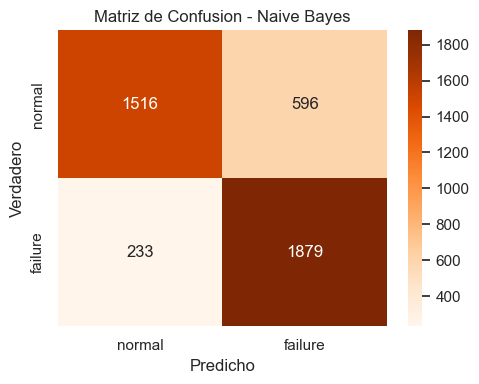

In [95]:
cm_nb = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Oranges', xticklabels=['normal','failure'], yticklabels=['normal','failure'])
plt.title('Matriz de Confusion - Naive Bayes')
plt.ylabel('Verdadero'); plt.xlabel('Predicho')
plt.tight_layout(); plt.show()

### Modelo 3 - K Vecinos Cercanos (KNN)

In [96]:
knn = KNeighborsClassifier()
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
grid_knn = GridSearchCV(estimator=knn, param_grid=param_grid_knn, scoring='f1', cv=cv, n_jobs=-1, verbose=1)
start_knn = time.perf_counter()
grid_knn.fit(X_train, y_train)
train_times['KNN'] = time.perf_counter() - start_knn
print('Mejores hiperparametros (KNN):', grid_knn.best_params_)
print('Mejor F1 en CV (KNN):', round(grid_knn.best_score_, 4))
model_memory['KNN'] = len(pickle.dumps(grid_knn.best_estimator_)) / 1024

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Mejores hiperparametros (KNN): {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Mejor F1 en CV (KNN): 0.9517


In [97]:
y_pred_knn = grid_knn.predict(X_test)
y_proba_knn = grid_knn.predict_proba(X_test)[:, 1]
acc_knn = accuracy_score(y_test, y_pred_knn)
prec_knn = precision_score(y_test, y_pred_knn)
rec_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)
auc_knn = roc_auc_score(y_test, y_proba_knn)
print('=== KNN - Test ===')
print(f'Accuracy : {acc_knn:.4f}')
print(f'Precision: {prec_knn:.4f}')
print(f'Recall   : {rec_knn:.4f}')
print(f'F1-Score : {f1_knn:.4f}')
print(f'ROC AUC  : {auc_knn:.4f}')
print(classification_report(y_test, y_pred_knn, target_names=['normal', 'failure']))

=== KNN - Test ===
Accuracy : 0.9517
Precision: 0.9236
Recall   : 0.9848
F1-Score : 0.9533
ROC AUC  : 0.9777
              precision    recall  f1-score   support

      normal       0.98      0.92      0.95      2112
     failure       0.92      0.98      0.95      2112

    accuracy                           0.95      4224
   macro avg       0.95      0.95      0.95      4224
weighted avg       0.95      0.95      0.95      4224



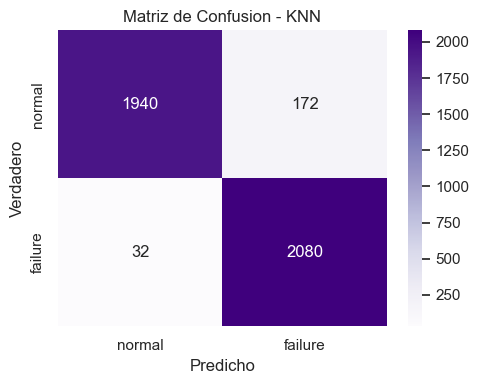

In [98]:
cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Purples', xticklabels=['normal','failure'], yticklabels=['normal','failure'])
plt.title('Matriz de Confusion - KNN')
plt.ylabel('Verdadero'); plt.xlabel('Predicho')
plt.tight_layout(); plt.show()

### Modelo 4 - Arbol de Decision

In [99]:
dt = DecisionTreeClassifier(random_state=42)
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}
grid_dt = GridSearchCV(estimator=dt, param_grid=param_grid_dt, scoring='f1', cv=cv, n_jobs=-1, verbose=1)
start_dt = time.perf_counter()
grid_dt.fit(X_train, y_train)
train_times['Arbol de Decision'] = time.perf_counter() - start_dt
print('Mejores hiperparametros (DT):', grid_dt.best_params_)
print('Mejor F1 en CV (DT):', round(grid_dt.best_score_, 4))
model_memory['Arbol de Decision'] = len(pickle.dumps(grid_dt.best_estimator_)) / 1024

Fitting 5 folds for each of 90 candidates, totalling 450 fits
Mejores hiperparametros (DT): {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Mejor F1 en CV (DT): 0.9563


In [100]:
y_pred_dt = grid_dt.predict(X_test)
y_proba_dt = grid_dt.predict_proba(X_test)[:, 1]
acc_dt = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt)
rec_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
auc_dt = roc_auc_score(y_test, y_proba_dt)
print('=== Arbol de Decision - Test ===')
print(f'Accuracy : {acc_dt:.4f}')
print(f'Precision: {prec_dt:.4f}')
print(f'Recall   : {rec_dt:.4f}')
print(f'F1-Score : {f1_dt:.4f}')
print(f'ROC AUC  : {auc_dt:.4f}')
print(classification_report(y_test, y_pred_dt, target_names=['normal', 'failure']))

=== Arbol de Decision - Test ===
Accuracy : 0.9515
Precision: 0.9470
Recall   : 0.9564
F1-Score : 0.9517
ROC AUC  : 0.9515
              precision    recall  f1-score   support

      normal       0.96      0.95      0.95      2112
     failure       0.95      0.96      0.95      2112

    accuracy                           0.95      4224
   macro avg       0.95      0.95      0.95      4224
weighted avg       0.95      0.95      0.95      4224



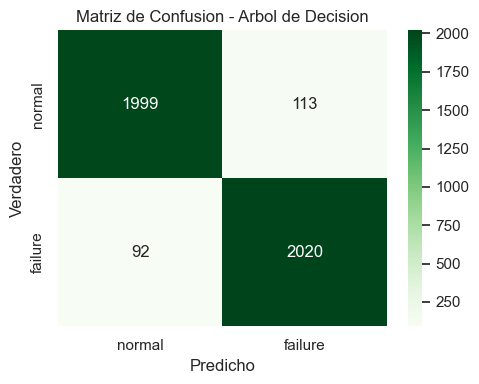

In [101]:
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', xticklabels=['normal','failure'], yticklabels=['normal','failure'])
plt.title('Matriz de Confusion - Arbol de Decision')
plt.ylabel('Verdadero'); plt.xlabel('Predicho')
plt.tight_layout(); plt.show()

### Modelo 5 - Random Forest (Bosque Aleatorio)

In [102]:
rf = RandomForestClassifier(random_state=42)
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'criterion': ['gini', 'entropy']
}
grid_rf = GridSearchCV(estimator=rf, param_grid=param_grid_rf, scoring='f1', cv=cv, n_jobs=-1, verbose=1)
start_rf = time.perf_counter()
grid_rf.fit(X_train, y_train)
train_times['Random Forest'] = time.perf_counter() - start_rf
print('Mejores hiperparametros (RF):', grid_rf.best_params_)
print('Mejor F1 en CV (RF):', round(grid_rf.best_score_, 4))
model_memory['Random Forest'] = len(pickle.dumps(grid_rf.best_estimator_)) / 1024

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Mejores hiperparametros (RF): {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Mejor F1 en CV (RF): 0.9662


In [103]:
y_pred_rf = grid_rf.predict(X_test)
y_proba_rf = grid_rf.predict_proba(X_test)[:, 1]
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)
print('=== Random Forest - Test ===')
print(f'Accuracy : {acc_rf:.4f}')
print(f'Precision: {prec_rf:.4f}')
print(f'Recall   : {rec_rf:.4f}')
print(f'F1-Score : {f1_rf:.4f}')
print(f'ROC AUC  : {auc_rf:.4f}')
print(classification_report(y_test, y_pred_rf, target_names=['normal', 'failure']))

=== Random Forest - Test ===
Accuracy : 0.9680
Precision: 0.9545
Recall   : 0.9830
F1-Score : 0.9685
ROC AUC  : 0.9958
              precision    recall  f1-score   support

      normal       0.98      0.95      0.97      2112
     failure       0.95      0.98      0.97      2112

    accuracy                           0.97      4224
   macro avg       0.97      0.97      0.97      4224
weighted avg       0.97      0.97      0.97      4224



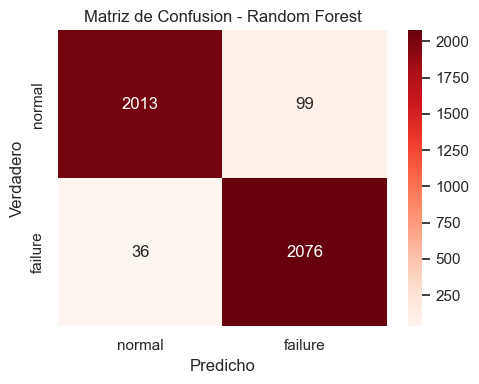

In [104]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Reds', xticklabels=['normal','failure'], yticklabels=['normal','failure'])
plt.title('Matriz de Confusion - Random Forest')
plt.ylabel('Verdadero'); plt.xlabel('Predicho')
plt.tight_layout(); plt.show()

### Modelo 6 - Gradient Boosting (Arboles Boosted)

In [105]:
gb = GradientBoostingClassifier(random_state=42)
param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5],
    'min_samples_split': [2, 5]
}
grid_gb = GridSearchCV(estimator=gb, param_grid=param_grid_gb, scoring='f1', cv=cv, n_jobs=-1, verbose=1)
start_gb = time.perf_counter()
grid_gb.fit(X_train, y_train)
train_times['Gradient Boosting'] = time.perf_counter() - start_gb
print('Mejores hiperparametros (GB):', grid_gb.best_params_)
print('Mejor F1 en CV (GB):', round(grid_gb.best_score_, 4))
model_memory['Gradient Boosting'] = len(pickle.dumps(grid_gb.best_estimator_)) / 1024

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Mejores hiperparametros (GB): {'learning_rate': 0.2, 'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}
Mejor F1 en CV (GB): 0.9719


In [106]:
y_pred_gb = grid_gb.predict(X_test)
y_proba_gb = grid_gb.predict_proba(X_test)[:, 1]
acc_gb = accuracy_score(y_test, y_pred_gb)
prec_gb = precision_score(y_test, y_pred_gb)
rec_gb = recall_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)
auc_gb = roc_auc_score(y_test, y_proba_gb)
print('=== Gradient Boosting - Test ===')
print(f'Accuracy : {acc_gb:.4f}')
print(f'Precision: {prec_gb:.4f}')
print(f'Recall   : {rec_gb:.4f}')
print(f'F1-Score : {f1_gb:.4f}')
print(f'ROC AUC  : {auc_gb:.4f}')
print(classification_report(y_test, y_pred_gb, target_names=['normal', 'failure']))

=== Gradient Boosting - Test ===
Accuracy : 0.9709
Precision: 0.9602
Recall   : 0.9825
F1-Score : 0.9712
ROC AUC  : 0.9961
              precision    recall  f1-score   support

      normal       0.98      0.96      0.97      2112
     failure       0.96      0.98      0.97      2112

    accuracy                           0.97      4224
   macro avg       0.97      0.97      0.97      4224
weighted avg       0.97      0.97      0.97      4224



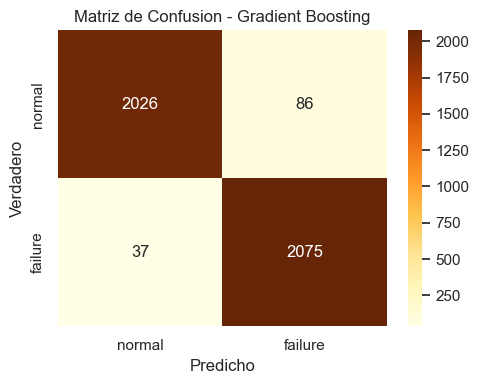

In [107]:
cm_gb = confusion_matrix(y_test, y_pred_gb)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='YlOrBr', xticklabels=['normal','failure'], yticklabels=['normal','failure'])
plt.title('Matriz de Confusion - Gradient Boosting')
plt.ylabel('Verdadero'); plt.xlabel('Predicho')
plt.tight_layout(); plt.show()

### Comparativa

,Metrica,Regresion Logistica,Naive Bayes,KNN,Arbol de Decision,Random Forest,Gradient Boosting
0,Accuracy,0.8355,0.8037,0.9517,0.9515,0.9680,0.9709
1,Precision,0.8303,0.7592,0.9236,0.9470,0.9545,0.9602
2,Recall,0.8433,0.8897,0.9848,0.9564,0.9830,0.9825
3,F1-Score,0.8367,0.8193,0.9533,0.9517,0.9685,0.9712
4,ROC AUC,0.9192,0.8884,0.9777,0.9515,0.9958,0.9961


,Modelo,Tiempo
0,Regresion Logistica,3.439688
1,Naive Bayes,0.070486
2,KNN,0.467780
3,Arbol de Decision,0.864378
4,Random Forest,18.369799
5,Gradient Boosting,17.080099



--- Memoria de modelos (KB) ---


,Memoria_KB
Modelo,
Regresion Logistica,0.9
Naive Bayes,1.0
KNN,766.0
Arbol de Decision,62.9
Random Forest,13449.6
Gradient Boosting,860.3



--- Benchmark completo (tiempo + memoria) ---


,Modelo,Tiempo,Memoria_KB
0,Regresion Logistica,3.4,0.9
1,Naive Bayes,0.1,1.0
2,KNN,0.5,766.0
3,Arbol de Decision,0.9,62.9
4,Random Forest,18.4,13449.6
5,Gradient Boosting,17.1,860.3


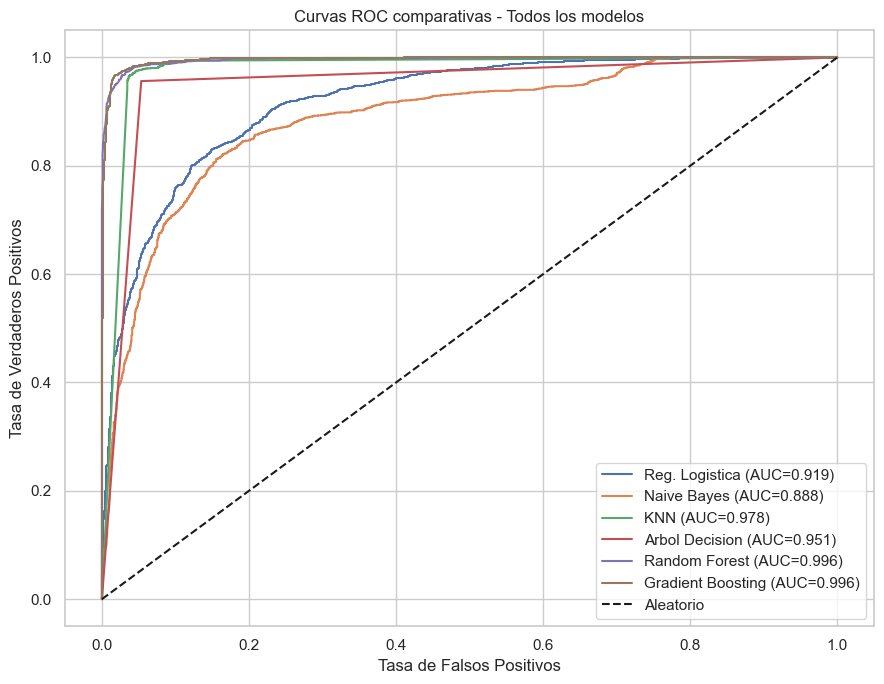

In [108]:
resultados = pd.DataFrame({
    'Metrica': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC'],
    'Regresion Logistica': [acc_lr, prec_lr, rec_lr, f1_lr, auc_lr],
    'Naive Bayes': [acc_nb, prec_nb, rec_nb, f1_nb, auc_nb],
    'KNN': [acc_knn, prec_knn, rec_knn, f1_knn, auc_knn],
    'Arbol de Decision': [acc_dt, prec_dt, rec_dt, f1_dt, auc_dt],
    'Random Forest': [acc_rf, prec_rf, rec_rf, f1_rf, auc_rf],
    'Gradient Boosting': [acc_gb, prec_gb, rec_gb, f1_gb, auc_gb]
})
resultados.iloc[:, 1:] = resultados.iloc[:, 1:].round(4)
display(resultados)
resultados.to_csv('resultados_modelos.csv', index=False)

order = [
    'Regresion Logistica',
    'Naive Bayes',
    'KNN',
    'Arbol de Decision',
    'Random Forest',
    'Gradient Boosting',
]
times_df = pd.DataFrame(
    [{'Modelo': name, 'Tiempo': train_times.get(name)} for name in order]
 )
times_df.to_csv('tiempos_modelos.csv', index=False)
display(times_df)

# Exportar memoria de modelos
mem_df = pd.DataFrame(
    [{'Modelo': name, 'Memoria_KB': model_memory.get(name, 0)} for name in order]
).set_index('Modelo')
mem_df.to_csv('memoria_modelos.csv')
print("\n--- Memoria de modelos (KB) ---")
display(mem_df.round(1))

# Concatenar tiempos y memoria en un solo CSV
bench_df = times_df.merge(mem_df, left_on="Modelo", right_index=True)
bench_df.to_csv("bench_modelos.csv", index=False)
print("\n--- Benchmark completo (tiempo + memoria) ---")
display(bench_df.round(1))

# Curvas ROC comparativas
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_proba_nb)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_proba_knn)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_proba_gb)

plt.figure(figsize=(9, 7))
plt.plot(fpr_lr, tpr_lr, label=f'Reg. Logistica (AUC={auc_lr:.3f})')
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC={auc_nb:.3f})')
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC={auc_knn:.3f})')
plt.plot(fpr_dt, tpr_dt, label=f'Arbol Decision (AUC={auc_dt:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={auc_rf:.3f})')
plt.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC={auc_gb:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC comparativas - Todos los modelos')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

## Notas finales sobre las decisiones de preprocesamiento y modelado

A continuacion se detallan los criterios adoptados durante el desarrollo del proyecto, los cuales fundamentan las transformaciones aplicadas al dataset `i40.csv` antes del entrenamiento de los modelos.

### 1) Preservacion de las caracteristicas de temperatura
Inicialmente se evaluo eliminar una de las variables de temperatura (`air_temp [K]` o `process_temp [K]`) debido a su alta correlacion positiva (~0.86). Sin embargo, dado el contexto del problema de mantenimiento predictivo industrial, ambas magnitudes aportan informacion fisica distinta: la temperatura del aire refleja condiciones ambientales o de refrigeracion, mientras que la temperatura del proceso representa el estado termico de la operacion. Para verificar la eficacia de mantener ambas caracteristicas, se probo iterativamente con **RFE manual** (Recursive Feature Elimination), comparando el rendimiento de los modelos con y sin cada variable. Los resultados mostraron que la inclusion de ambas temperaturas mejora o mantiene las metricas de clasificacion, por lo que se decidio conservarlas.

### 2) Estrategia de balanceo: Undersampling
La variable objetivo `target` se encontraba relativamente cercana al equilibrio (~51.5 % `failure` y ~48.5 % `normal`). Ante esta situacion, se descarto el uso de tecnicas de oversampling sintetico (como SMOTE) que podrian introducir ruido o sobreajuste. En su lugar, se aplico **RandomUnderSampler** para reducir la clase mayoritaria (`normal`) hasta igualar la cantidad de la minoritaria (`failure`), obteniendo un dataset balanceado 50/50 sin generar observaciones artificiales.

### 3) Imputacion de valores anomalos en `speed [RPM]` (RPM <= 0)
Se detectaron 47 registros con valores de `speed [RPM]` menores o iguales a cero, lo cual es fisicamente inconsistente en un proceso rotativo. Dado que `speed [RPM]` y `torque [Nm]` presentan una **correlacion negativa muy alta (~-0.89)** y una relacion de causalidad real en sistemas mecanicos (a mayor velocidad, menor torque para una misma potencia), se utilizo un modelo de **KMeans** entrenado sobre el par `(torque, speed)`. Los centroides del cluster mas cercano en la dimension del torque permitieron estimar el valor de RPM faltante de forma coherente con el comportamiento fisico del equipo.

### 4) Imputacion de valores nulos en `air_temp [K]`
Se identificaron 40 valores faltantes en la temperatura del aire. Siguiendo el mismo criterio del punto anterior, y aprovechando la alta correlacion entre `air_temp [K]` y `process_temp [K]` (~0.86), se aplico **KMeans** sobre el par `(process_temp, air_temp)`. De este modo, los registros con temperatura del aire faltante fueron completados tomando el valor del centroide correspondiente segun su temperatura de proceso, respetando la relacion termica existente entre ambas variables.

### Resumen de la pipeline
1. Limpieza de identificadores y duplicados.  
2. Correccion de RPM <= 0 e imputacion conjunta de pares correlacionados mediante **KMeans**.  
3. Eliminacion de variables altamente correlacionadas solo cuando no aportan informacion de dominio (en este caso se mantuvieron ambas temperaturas tras validacion con RFE manual).  
4. Normalizacion estandar (z-score) de variables numericas.  
5. One-hot encoding de la variable categorica `product_type`.  
6. Division estratificada en entrenamiento (70 %) y prueba (30 %).  
7. Entrenamiento y busqueda de hiperparametros con `GridSearchCV` sobre seis modelos de clasificacion.